# Import libraries

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import retrieve, combine, path

# Load data

We shall reuse the data extraction code provided in this link (https://physionet.org/content/ptb-xl/1.0.3/), rather than re-implement everything from scratch.

Note that, we use the `sampling_rate = 100`, meaning that we specifically utilise the `records100/` data to conduct the experiment. Therefore, in total, there are **21799** files, and:

- `X` contains **1000** frames (10 seconds sampled at 100 Hz) across **12** leads independently.

- `Y` contains the `ptbxl_database.csv` (other demographic data) and an additional column, namely `diagnostic_superclass`, which is our target of interest.

The `records100/` is the downsampled version of `records500/`.

We further highlight that, for sake of comparison fairness, the original paper only uses `X` for modelling purposes, we shall confine ourselves to inspect the `X`, with an aggregated target `diagostic_superclass`.

In [2]:
X, Y = retrieve()

In [3]:
print(f"X size is: {X.shape}")
print(f"Y size is: {Y.shape}")

X size is: (21799, 1000, 12)
Y size is: (21799, 28)


In [4]:
X[1]

array([[ 0.004,  0.138,  0.134, ...,  0.192,  0.083,  0.088],
       [-0.02 ,  0.116,  0.136, ...,  0.156,  0.057,  0.063],
       [-0.053,  0.092,  0.145, ...,  0.107,  0.013,  0.022],
       ...,
       [ 0.121,  0.398,  0.277, ..., -1.065, -0.492, -0.156],
       [-0.326,  0.057,  0.383, ..., -0.28 , -0.175, -0.071],
       [-0.348, -0.056,  0.292, ..., -0.308, -0.231, -0.145]],
      shape=(1000, 12), dtype=float32)

In [5]:
Y.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]


In [6]:
y = Y.iloc[:, -1]
y.head(5)

ecg_id
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
5    [NORM]
Name: diagnostic_superclass, dtype: object

# Exploratory Data Analysis (EDA)

## Diagnosis classes

### Target uniqueness

Interestingly, a patient might be diagnosed with more than one superclass, and there exist some patients were not diagnosed with any superclasses, we treat these as missing values.

This is not an error, since according to their description, the five superclasses 

In [7]:
np.unique(y)

array([list([]), list(['CD']), list(['CD', 'STTC']), list(['HYP']),
       list(['HYP', 'CD']), list(['HYP', 'CD', 'STTC']),
       list(['HYP', 'MI']), list(['HYP', 'MI', 'CD']),
       list(['HYP', 'MI', 'CD', 'STTC']),
       list(['HYP', 'MI', 'NORM', 'CD']), list(['HYP', 'MI', 'STTC']),
       list(['HYP', 'NORM']), list(['HYP', 'NORM', 'CD']),
       list(['HYP', 'STTC']), list(['MI']), list(['MI', 'CD']),
       list(['MI', 'CD', 'STTC']), list(['MI', 'STTC']), list(['NORM']),
       list(['NORM', 'CD']), list(['NORM', 'CD', 'STTC']),
       list(['NORM', 'STTC']), list(['STTC'])], dtype=object)

### Imbalance?

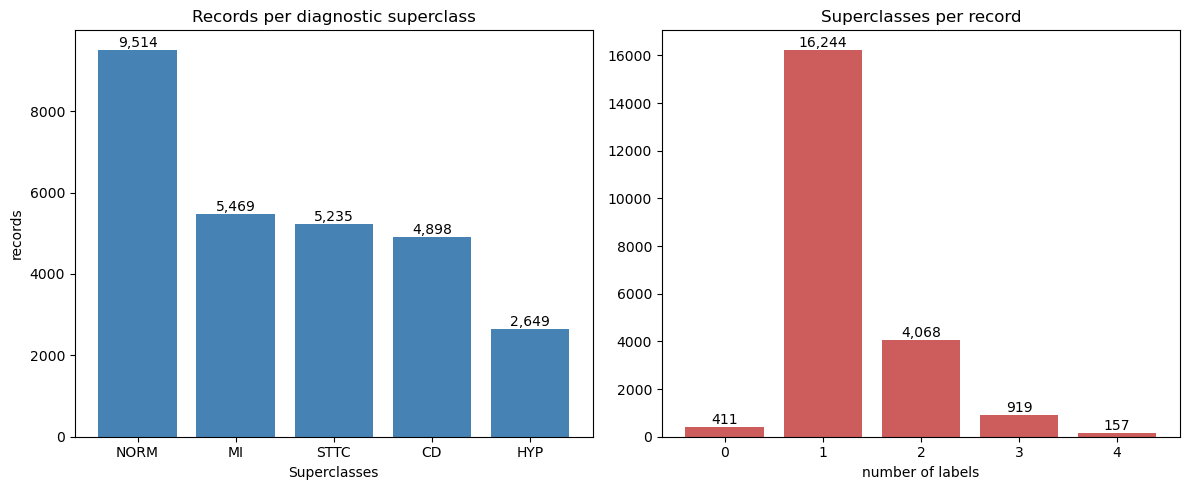

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

counts = y.explode().value_counts()
axes[0].bar(counts.index, counts.values, color = "steelblue")
axes[0].set_title("Records per diagnostic superclass")
axes[0].set_ylabel("records")
axes[0].set_xlabel("Superclasses")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha = "center", va = "bottom")

n_labels = y.str.len().value_counts().sort_index()
axes[1].bar(n_labels.index.astype(str), n_labels.values, color = "indianred")
axes[1].set_title("Superclasses per record")
axes[1].set_xlabel("number of labels")
for i, v in enumerate(n_labels.values):
    axes[1].text(i, v, f"{v:,}", ha = "center", va = "bottom")

plt.tight_layout()
plt.show()

### Focusing on single-label records

We shall visualise the data distribution by limiting to those diagnosed with 1 superclass. From now on, we only work with this reduced dataset.

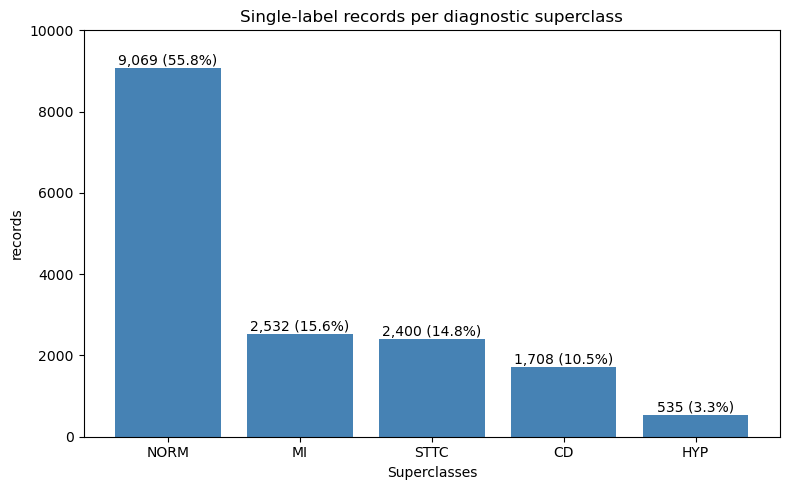

In [ ]:
df_single = pd.read_parquet("../data/ptbxl100_single.parquet")
y_single = df_single.loc[:, "diagnostic_superclass"]

fig, ax = plt.subplots(figsize = (8, 5))

counts = y_single.value_counts()
ax.bar(counts.index, counts.values, color = "steelblue")
ax.set_title("Single-label records per diagnostic superclass")
ax.set_ylabel("records")
ax.set_xlabel("Superclasses")
ax.set_ylim(0, 10000)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,} ({v / len(y_single):.1%})", ha = "center", va = "bottom")

plt.tight_layout()
plt.show()

### Saving the single-label set

`combine()` pairs each signal with its `patient_id` and label in one table, written to `data/ptbxl100_single.parquet`.

In [ ]:
# single = y.str.len() == 1

# X_single = X[single.values]
# Y_single = Y[single].assign(diagnostic_superclass = y[single].str[0])
# y_single = Y_single["diagnostic_superclass"]

# print(f"single-label subset: {single.sum():,} of {len(y):,} records ({single.mean():.1%})")
# print(f"X_single: {X_single.shape}   Y_single: {Y_single.shape}")

# df_single = combine(X_single, Y_single)
# df_single.to_parquet(path + "ptbxl100_single.parquet")

print(df_single.shape)
df_single.head()

(16244, 3)


,patient_id,diagnostic_superclass,signal
ecg_id,,,
1,15709.0,NORM,"[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004, ..."
2,13243.0,NORM,"[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, -..."
3,20372.0,NORM,"[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064,..."
4,17014.0,NORM,"[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11, ..."
5,17448.0,NORM,"[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556, ..."


## ECG signal

### Visualisation of 12 leads

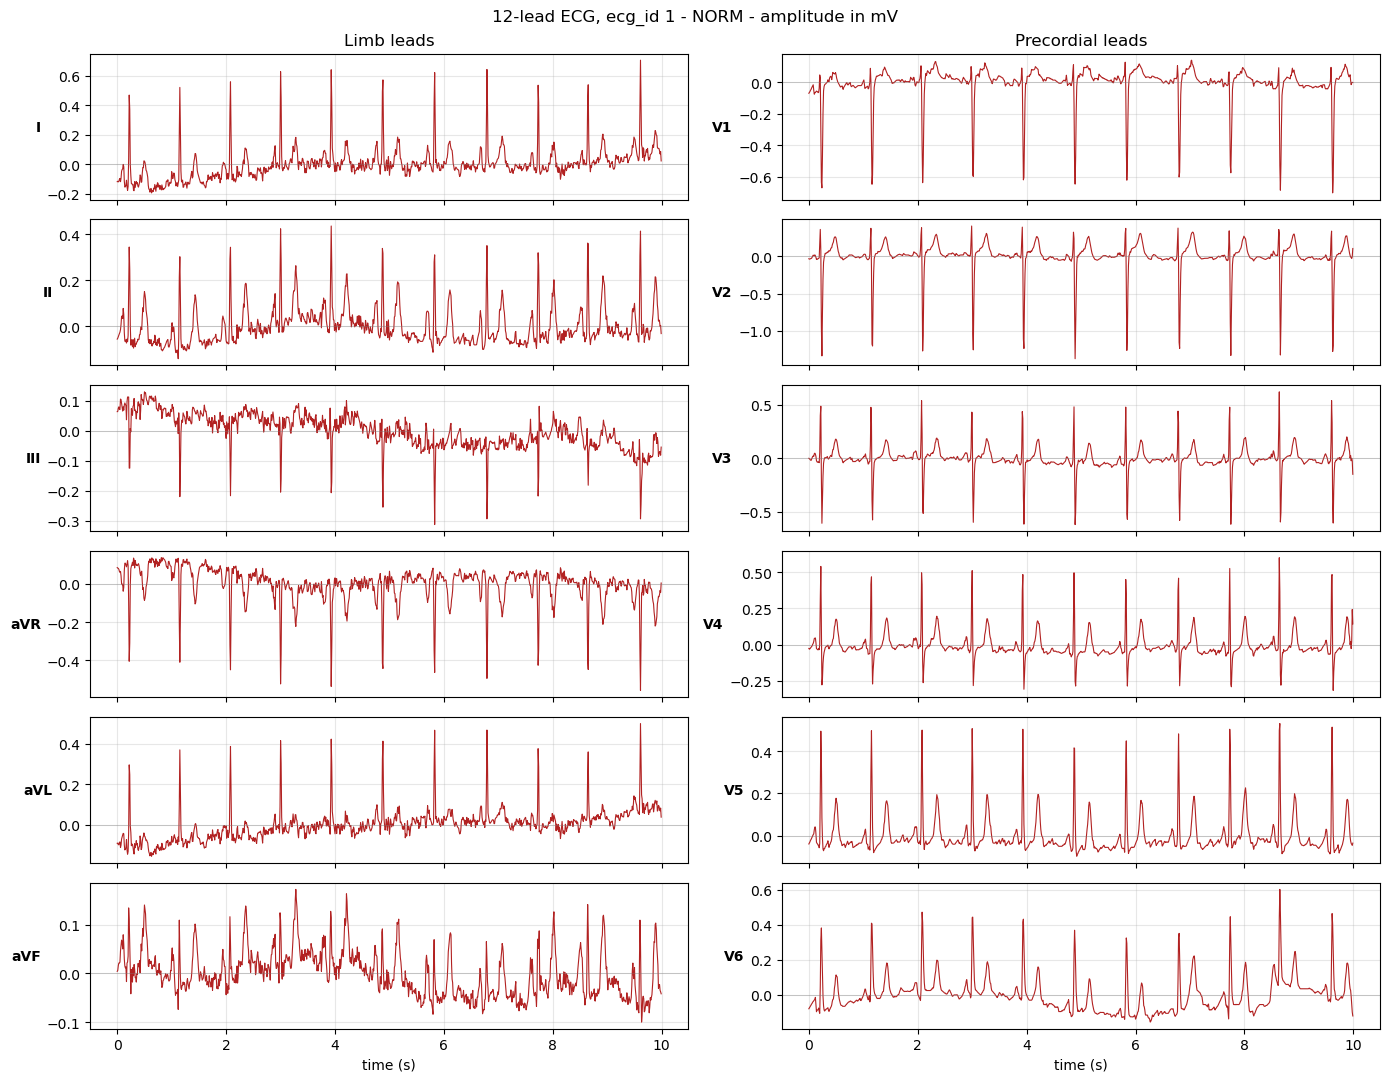

In [ ]:
# Lead order is fixed by the WFDB headers.
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

sample = df_single["signal"].iloc[0].reshape(1000, 12)
time = np.arange(sample.shape[0]) / 100      # 100 Hz -> seconds

fig, axes = plt.subplots(6, 2, figsize = (14, 11), sharex = True)

for i, ax in enumerate(axes.T.flatten()):
    ax.plot(time, sample[:, i], linewidth = 0.8, color = "firebrick")
    ax.set_ylabel(LEADS[i], rotation = 0, ha = "right", va = "center", fontweight = "bold")
    ax.axhline(0, color = "grey", linewidth = 0.5, alpha = 0.5)
    ax.grid(alpha = 0.3)

for ax in axes[-1]:
    ax.set_xlabel("time (s)")

axes[0, 0].set_title("Limb leads")
axes[0, 1].set_title("Precordial leads")

label = df_single["diagnostic_superclass"].iloc[0]
fig.suptitle(f"12-lead ECG, ecg_id {df_single.index[0]} - {label} - amplitude in mV")
plt.tight_layout()
plt.show()

### Missing values

A missing sample in an ECG would surface in one of two ways, either as `NaN`/`Inf` or as a
lead that never moves across the full 10 seconds (a disconnected electrode). We check both, then look at how close any lead comes to flat.

X_single: (16244, 1000, 12)

NaN values: 0    Inf values: 0
dead (zero-variance) leads: 0

near-flat leads by threshold:
  std < 0.005 mV:     0 leads in     0 records
  std < 0.010 mV:     0 leads in     0 records
  std < 0.020 mV:     5 leads in     5 records
  std < 0.050 mV: 4,119 leads in 3,416 records


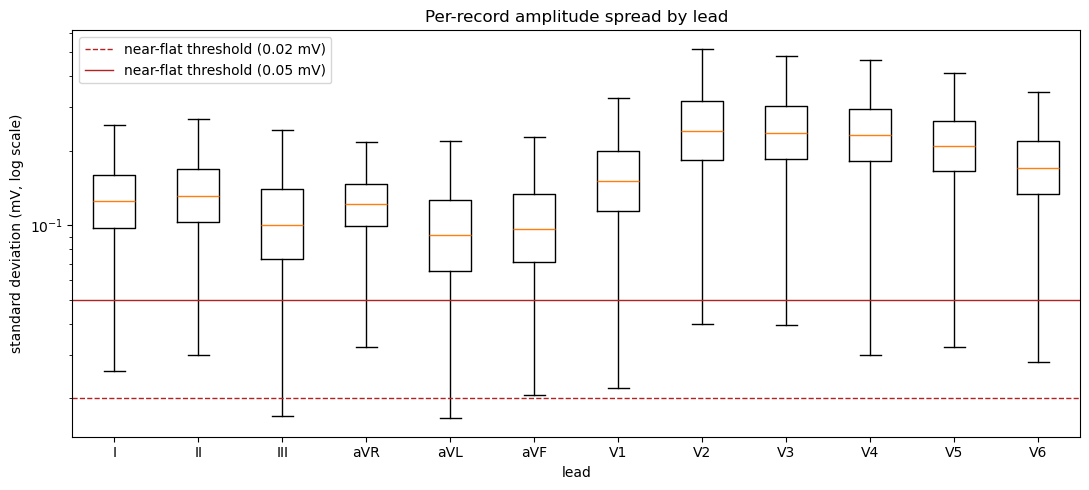

In [47]:
X_single = np.stack(df_single["signal"].values).reshape(-1, 1000, 12)
print(f"X_single: {X_single.shape}")

# 1. Absent or non-finite samples.
print(f"\nNaN values: {np.isnan(X_single).sum():,}    Inf values: {np.isinf(X_single).sum():,}")

# 2. A lead flat across all 10 s is effectively missing even though it holds no NaN.
std = X_single.std(axis = 1)
dead = np.argwhere(std == 0)
print(f"dead (zero-variance) leads: {len(dead)}")

for r, l in dead:
    print(f"  ecg_id {df_single.index[r]}, lead {LEADS[l]}")

# How close does any lead come to flat?
print("\nnear-flat leads by threshold:")
for threshold in [0.005, 0.01, 0.02, 0.05]:
    near = std < threshold
    print(f"  std < {threshold:.3f} mV: {near.sum():5,} leads in {near.any(axis = 1).sum():5,} records")

fig, ax = plt.subplots(figsize = (11, 5))

ax.boxplot([std[:, i] for i in range(12)], tick_labels = LEADS, showfliers = False)
ax.set_yscale("log")
ax.axhline(0.02, color = "firebrick", linestyle = "--", linewidth = 1,
           label = "near-flat threshold (0.02 mV)")
ax.axhline(0.05, color = "firebrick", linestyle = "-", linewidth = 1,
           label = "near-flat threshold (0.05 mV)")
ax.set_title("Per-record amplitude spread by lead")
ax.set_ylabel("standard deviation (mV, log scale)")
ax.set_xlabel("lead")
ax.legend()

plt.tight_layout()
plt.show()